# Multiple Linear Regression

## Importing the libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [78]:
df=pd.read_csv(r'economic_index.csv')

In [79]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [80]:
df.drop(['Unnamed: 0','year','month'],axis=1,inplace=True)

In [81]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


## Seperating the Independent and Dependent Features

In [82]:
X=df[['interest_rate','unemployment_rate']]
y=df['index_price']

X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [83]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

## Splitting Data into Training and Testing Data

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

## Visualizing Data

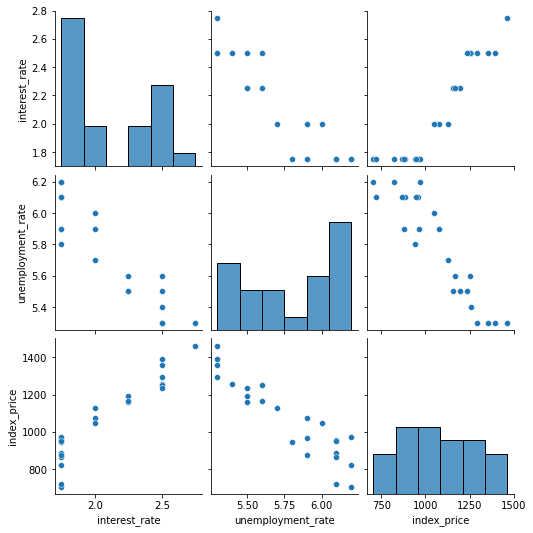

In [85]:
sns.pairplot(df);

In [86]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


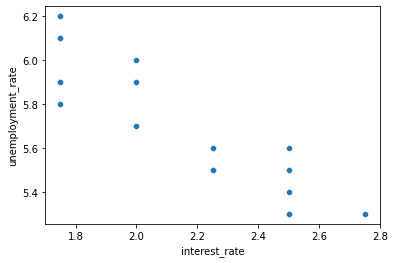

In [87]:
sns.scatterplot(x='interest_rate',y='unemployment_rate',data=df);

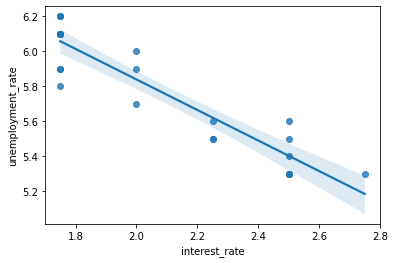

In [88]:
sns.regplot(x='interest_rate',y='unemployment_rate',data=df);

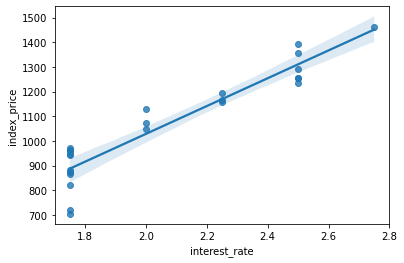

In [89]:
sns.regplot(x='interest_rate',y='index_price',data=df);

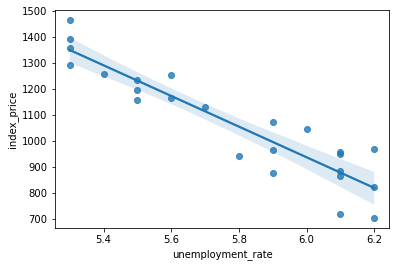

In [90]:
sns.regplot(x='unemployment_rate',y='index_price',data=df);

## Standardizing the Data

In [91]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Applying Linear Regression 

In [92]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

regression.fit(X_train,y_train)
y_pred=regression.predict(X_test)

y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [117]:
print(f"Linear Regression\n")
print(f'Intercept: {regression.intercept_:.2f}')
print(f'Coefficient: [{regression.coef_[0]:.2f}, {regression.coef_[1]:.2f}]')

Linear Regression

Intercept: 1053.44
Coefficient: [88.27, -116.26]


## Cross Validation

In [93]:
from sklearn.model_selection import cross_val_score

validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=5)
validation_score

array([-1861.74046551, -8715.8459466 , -7707.52362191, -9169.13776461,
        -791.32842311])

In [94]:
np.mean(validation_score)

-5649.11524435076

## Performance Metrics 

In [95]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

print('MSE: ',mean_squared_error(y_pred,y_test))
print('RMSE: ',root_mean_squared_error(y_pred,y_test))
print('MAE: ',mean_absolute_error(y_pred,y_test))
print('R2 Score: ',r2_score(y_pred,y_test))
score=r2_score(y_pred,y_test)
print('Adjusted R2 score: ',1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

MSE:  5793.762887712579
RMSE:  76.11677139574812
MAE:  59.935781523235526
R2 Score:  0.8626502528670699
Adjusted R2 score:  0.7710837547784498


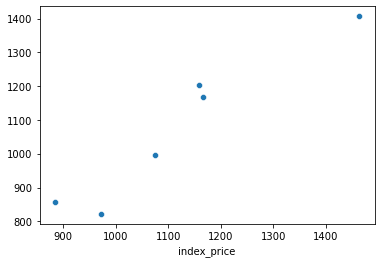

In [96]:
sns.scatterplot(y_test,y_pred);

In [97]:
residuals=y_pred-y_test
print(residuals)

8      45.227704
16   -149.349481
0     -57.486996
18    -26.291104
11    -80.090077
9       1.169327
Name: index_price, dtype: float64


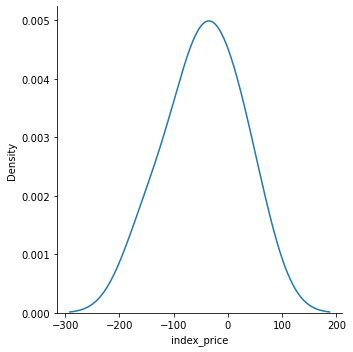

In [98]:
sns.displot(residuals,kind='kde');

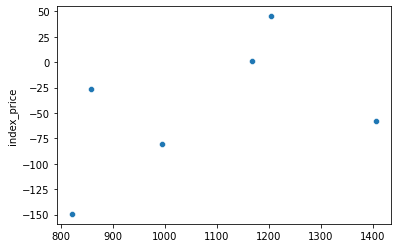

In [99]:
sns.scatterplot(y_pred,residuals);

## Linear Regression using OLS(Ordinary Least Squares)

In [118]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [119]:
model.predict(X_test)

array([ 150.78325954, -231.79392541,  353.06855924, -195.73554836,
        -58.53452146,  114.72488249])

In [120]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Fri, 08 May 2026   Prob (F-statistic):                       0.754
Time:                        23:08:54   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""